# Experimenting with the MNIST Dataset

In [1]:
import torch
from torch import Tensor
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

In [2]:
train_dataset = datasets.MNIST(
    root="./data", train=True, download=True, transform=transforms.ToTensor()
)
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=1, shuffle=True
)
print(f'We have {len(train_loader)} training examples')

We have 60000 training examples


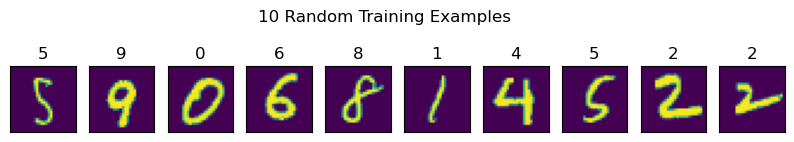

In [3]:
train_iter = iter(train_loader)

n = 10

fig, axes = plt.subplots(1, n, figsize=(n, 4))
for i in range(n):
    images, labels = next(train_iter)
    image: Tensor = images[0]
    label: int = labels[0]
    axes[i].imshow(images[0].squeeze())
    axes[i].set_title(f'{label}')
    axes[i].set_xticks([])
    axes[i].set_yticks([])
fig.subplots_adjust(top=1.4)
fig.suptitle(f'{n} Random Training Examples')
plt.show()

Shown below is the shape of the images. They are tensors of shape $(1, 1, 28, 28)$. The first dimension is created by the `train_loader`, the next three dimensions are created by the `ToTensor` dataset transform.

- First dimension is the batch dimension. We set it to $1$ in the `train_loader` above, but we will increase it when training.

- Second dimension is the channel dimension. Since MNIST images are grayscale they only have 1 channel (instead of the usual 3 channels for R G B).

- Third dimension is height. MNIST images are 28 pixels high.

- Fourth dimension is width. MNIST images are 28 pixels wide.

In [4]:
next(train_iter)[0].shape

torch.Size([1, 1, 28, 28])

Next we'll calculate the mean and standard deviation of the dataset so that we can normalize it properly before training.

In [5]:
def calculate_mean(loader: torch.utils.data.DataLoader) -> float:
    total_sum: float = 0.0
    total_pixels: int = 0

    x: Tensor
    for x, _ in loader:
        total_sum += x.sum()
        total_pixels += x.numel() # Alternatively can just do `+= 28*28`

    return (total_sum / total_pixels).item()

def calculate_std(loader: torch.utils.data.DataLoader, mean: float) -> float:
    squared_diff_sum: float = 0.0
    total_pixels: int = 0

    x: Tensor
    for x, _ in loader:
        squared_diff_sum += ((x - mean)**2).sum()
        total_pixels += x.numel() # Alternatively can just do `+= 28*28`

    return (squared_diff_sum / total_pixels).sqrt().item()

In [6]:
x_mean = calculate_mean(train_loader)
x_std = calculate_std(train_loader, x_mean)
x_mean, x_std

(0.13066014647483826, 0.30810779333114624)

Now that we know the mean and standard deviation of the dataset, we can normalize it properly. After this transformation, the dataset should have a mean of 0 and standard deviation of 1.

In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),                    # (C, H, W)
    transforms.Normalize((x_mean,), (x_std,)) # (C, H, W)
])

In [8]:
train_dataset = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=1, shuffle=True
)
normalized_x_mean = calculate_mean(train_loader)
normalized_x_std = calculate_std(train_loader, normalized_x_mean)
normalized_x_mean, normalized_x_std

(1.0985697826981777e-06, 1.0000001192092896)

## Training

In [9]:
import torch
import torch.nn.functional as F

import mnist

In [10]:
if torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'
print(f'Using {device}')

Using cuda


In [11]:
@torch.no_grad()
def estimate_loss(model: torch.nn.Module, loader: torch.utils.data.DataLoader, eval_iterations: int, flatten: bool = False) -> torch.types.Number:
    losses = torch.zeros((eval_iterations,), dtype=torch.float32)
    correct = 0.0
    total = 0

    i = 0
    images: Tensor # (B, 1, H, W)
    labels: Tensor # (B,)
    for images, labels in loader:
        if  i == eval_iterations:
            break

        x = images.to(device)
        if flatten:
            x = x.view(-1, 28*28)
        y = labels.to(device)

        output = model(x)
        loss: Tensor = F.cross_entropy(output, y)

        losses[i] = loss.item()

        predictions = torch.argmax(output, dim=1)
        correct += (predictions == y).sum().item()
        total += predictions.shape[0]

        i += 1

    return losses.mean().item(), correct / total

In [12]:
def train(model: torch.nn.Module, train_loader: torch.utils.data.DataLoader, val_loader: torch.utils.data.DataLoader, epochs: int, max_lr: float, min_lr: float, flatten: bool = False):
    optimizer = torch.optim.SGD(model.parameters(), lr=max_lr)
    gamma = (min_lr / max_lr)**(1.0 / epochs)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=gamma)

    model.train()
    epoch = 0

    while True:
        train_loss, train_accuracy = estimate_loss(model, train_loader, 100, flatten=flatten)
        val_loss, val_accuracy = estimate_loss(model, val_loader, 100, flatten=flatten)
        print(f'epoch: {epoch}, lr: {scheduler.get_last_lr()[0]:.4f}, train loss: {train_loss:.4f}, train accuracy: {train_accuracy:.4f}, val loss: {val_loss:.4f}, val accuracy: {val_accuracy:.4f}')

        if epoch == epochs:
            break
        epoch += 1

        images: Tensor # (B, 1, H, W)
        labels: Tensor # (B,)

        for images, labels in train_loader:
            x = images.to(device)
            if flatten:
                x = x.view(-1, 28*28)
            y = labels.to(device)
            model.zero_grad()
            output = model(x)
            loss: Tensor = F.cross_entropy(output, y)

            loss.backward()
            optimizer.step()

        scheduler.step()

In [13]:
train_dataset = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
val_dataset = datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

batch_size = 64

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=batch_size, shuffle=True
)

In [14]:
model = mnist.model.mlp.MLP([28*28, 10])
model.to(device)
train(model, train_loader, val_loader, epochs=10, max_lr=0.01, min_lr=0.001, flatten=True)

epoch: 0, lr: 0.0100, train loss: 2.3868, train accuracy: 0.1183, val loss: 2.4057, val accuracy: 0.1117
epoch: 1, lr: 0.0079, train loss: 0.3498, train accuracy: 0.9008, val loss: 0.3379, val accuracy: 0.9044
epoch: 2, lr: 0.0063, train loss: 0.3052, train accuracy: 0.9150, val loss: 0.3139, val accuracy: 0.9116
epoch: 3, lr: 0.0050, train loss: 0.3326, train accuracy: 0.9047, val loss: 0.2953, val accuracy: 0.9139
epoch: 4, lr: 0.0040, train loss: 0.2962, train accuracy: 0.9169, val loss: 0.3004, val accuracy: 0.9158
epoch: 5, lr: 0.0032, train loss: 0.2928, train accuracy: 0.9187, val loss: 0.2994, val accuracy: 0.9145
epoch: 6, lr: 0.0025, train loss: 0.2935, train accuracy: 0.9158, val loss: 0.2938, val accuracy: 0.9183
epoch: 7, lr: 0.0020, train loss: 0.2892, train accuracy: 0.9195, val loss: 0.2947, val accuracy: 0.9175
epoch: 8, lr: 0.0016, train loss: 0.2856, train accuracy: 0.9184, val loss: 0.2878, val accuracy: 0.9198
epoch: 9, lr: 0.0013, train loss: 0.2994, train accurac

In [15]:
model = mnist.model.mlp.MLP([28*28, 28*28*4, 28*28*16, 28*28*4, 10])
model.to(device)
train(model, train_loader, val_loader, epochs=10, max_lr=0.01, min_lr=0.001, flatten=True)

epoch: 0, lr: 0.0100, train loss: 2.2969, train accuracy: 0.1389, val loss: 2.2965, val accuracy: 0.1420
epoch: 1, lr: 0.0079, train loss: 0.2991, train accuracy: 0.9137, val loss: 0.3059, val accuracy: 0.9119
epoch: 2, lr: 0.0063, train loss: 0.2940, train accuracy: 0.9170, val loss: 0.2742, val accuracy: 0.9205
epoch: 3, lr: 0.0050, train loss: 0.2744, train accuracy: 0.9222, val loss: 0.2867, val accuracy: 0.9223
epoch: 4, lr: 0.0040, train loss: 0.2657, train accuracy: 0.9255, val loss: 0.2756, val accuracy: 0.9225
epoch: 5, lr: 0.0032, train loss: 0.2756, train accuracy: 0.9194, val loss: 0.2819, val accuracy: 0.9202
epoch: 6, lr: 0.0025, train loss: 0.2720, train accuracy: 0.9258, val loss: 0.2796, val accuracy: 0.9203
epoch: 7, lr: 0.0020, train loss: 0.2633, train accuracy: 0.9278, val loss: 0.2707, val accuracy: 0.9233
epoch: 8, lr: 0.0016, train loss: 0.2609, train accuracy: 0.9253, val loss: 0.2764, val accuracy: 0.9236
epoch: 9, lr: 0.0013, train loss: 0.2562, train accurac

In [16]:
model = mnist.model.cnn.CNN()
model.to(device)
train(model, train_loader, val_loader, epochs=10, max_lr=0.01, min_lr=0.001, flatten=False)

/home/daniel/miniconda3/envs/ml_cuda12.2/lib/python3.12/site-packages/torch/nn/modules/conv.py:549: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /opt/conda/conda-bld/pytorch_1729647378361/work/aten/src/ATen/native/Convolution.cpp:1036.)
  return F.conv2d(


epoch: 0, lr: 0.0100, train loss: 2.3680, train accuracy: 0.0927, val loss: 2.3759, val accuracy: 0.0864
epoch: 1, lr: 0.0079, train loss: 0.1516, train accuracy: 0.9550, val loss: 0.1320, val accuracy: 0.9606
epoch: 2, lr: 0.0063, train loss: 0.0817, train accuracy: 0.9777, val loss: 0.0775, val accuracy: 0.9764
epoch: 3, lr: 0.0050, train loss: 0.0746, train accuracy: 0.9791, val loss: 0.0680, val accuracy: 0.9798
epoch: 4, lr: 0.0040, train loss: 0.0580, train accuracy: 0.9841, val loss: 0.0655, val accuracy: 0.9784
epoch: 5, lr: 0.0032, train loss: 0.0497, train accuracy: 0.9862, val loss: 0.0561, val accuracy: 0.9825
epoch: 6, lr: 0.0025, train loss: 0.0475, train accuracy: 0.9859, val loss: 0.0567, val accuracy: 0.9820
epoch: 7, lr: 0.0020, train loss: 0.0459, train accuracy: 0.9880, val loss: 0.0509, val accuracy: 0.9834
epoch: 8, lr: 0.0016, train loss: 0.0388, train accuracy: 0.9909, val loss: 0.0543, val accuracy: 0.9833
epoch: 9, lr: 0.0013, train loss: 0.0390, train accurac

In [17]:
model = mnist.model.cnn.CNN2()
model.to(device)
train(model, train_loader, val_loader, epochs=10, max_lr=0.01, min_lr=0.001, flatten=False)

epoch: 0, lr: 0.0100, train loss: 2.3133, train accuracy: 0.0933, val loss: 2.3129, val accuracy: 0.0900
epoch: 1, lr: 0.0079, train loss: 0.1336, train accuracy: 0.9627, val loss: 0.1097, val accuracy: 0.9670
epoch: 2, lr: 0.0063, train loss: 0.0790, train accuracy: 0.9783, val loss: 0.0796, val accuracy: 0.9764
epoch: 3, lr: 0.0050, train loss: 0.0739, train accuracy: 0.9781, val loss: 0.0672, val accuracy: 0.9802
epoch: 4, lr: 0.0040, train loss: 0.0574, train accuracy: 0.9833, val loss: 0.0563, val accuracy: 0.9817
epoch: 5, lr: 0.0032, train loss: 0.0524, train accuracy: 0.9850, val loss: 0.0546, val accuracy: 0.9816
epoch: 6, lr: 0.0025, train loss: 0.0520, train accuracy: 0.9861, val loss: 0.0489, val accuracy: 0.9844
epoch: 7, lr: 0.0020, train loss: 0.0452, train accuracy: 0.9859, val loss: 0.0479, val accuracy: 0.9848
epoch: 8, lr: 0.0016, train loss: 0.0378, train accuracy: 0.9897, val loss: 0.0469, val accuracy: 0.9856
epoch: 9, lr: 0.0013, train loss: 0.0440, train accurac

In [18]:
model = mnist.model.cnn.CNN2()
model.to(device)
train(model, train_loader, val_loader, epochs=50, max_lr=0.005, min_lr=0.0001, flatten=False)

epoch: 0, lr: 0.0050, train loss: 2.3072, train accuracy: 0.0775, val loss: 2.3088, val accuracy: 0.0734
epoch: 1, lr: 0.0046, train loss: 0.1928, train accuracy: 0.9487, val loss: 0.1966, val accuracy: 0.9478
epoch: 2, lr: 0.0043, train loss: 0.1163, train accuracy: 0.9666, val loss: 0.1155, val accuracy: 0.9645
epoch: 3, lr: 0.0040, train loss: 0.0942, train accuracy: 0.9739, val loss: 0.0869, val accuracy: 0.9742
epoch: 4, lr: 0.0037, train loss: 0.0825, train accuracy: 0.9745, val loss: 0.0692, val accuracy: 0.9778
epoch: 5, lr: 0.0034, train loss: 0.0654, train accuracy: 0.9800, val loss: 0.0640, val accuracy: 0.9808
epoch: 6, lr: 0.0031, train loss: 0.0615, train accuracy: 0.9823, val loss: 0.0571, val accuracy: 0.9827
epoch: 7, lr: 0.0029, train loss: 0.0600, train accuracy: 0.9819, val loss: 0.0538, val accuracy: 0.9830
epoch: 8, lr: 0.0027, train loss: 0.0485, train accuracy: 0.9866, val loss: 0.0522, val accuracy: 0.9839
epoch: 9, lr: 0.0025, train loss: 0.0495, train accurac